# 03 - Backtest: Regime-Based Allocation for a Euro Investor

**Question:** if an investor had followed the regime model in real time, with publication lags and trading costs, would they have done better than a static portfolio?

**Inputs:** `data/returns_eur.csv`, `data/returns_usd.csv`, `data/regimes.csv`
**Period:** 2006 – September 2026 (monthly)

## 1. Design

**Investor:** euro-based, using euro returns and Euro area regimes.

**Avoiding look-ahead bias:**
- **Publication lags.** A regime can only be used once all its data has been published. For the Euro area, the Economic Sentiment Indicator and Eurostat's flash inflation estimate are both published at the end of the month they describe, so the September regime is known by early October and can first be used for October returns: a **1-month lag**. For the US, CPI and industrial production are published around mid-month, so the lag is **2 months**.
- **Tilts set in advance.** The regime tilts are based on economic reasoning, not on the results of `02_asset_returns`. Choosing tilts from the same data used to test them would make the backtest look better than it could have been in reality.

**Trading costs:** 0.1% of every euro traded. Portfolios are rebalanced monthly.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

returns_eur = pd.read_csv("../data/returns_eur.csv", index_col=0, parse_dates=True)
returns_usd = pd.read_csv("../data/returns_usd.csv", index_col=0, parse_dates=True)
regimes = pd.read_csv("../data/regimes.csv", index_col=0, parse_dates=True)

LAG_EA = 1
LAG_US = 2

signal_ea = regimes["ea_regime"].shift(LAG_EA, freq="MS")
signal_us = regimes["us_regime"].shift(LAG_US, freq="MS")

pd.DataFrame({"ea_regime": regimes["ea_regime"], "signal_ea": signal_ea}).loc["2020-01":"2020-08"]

,ea_regime,signal_ea
2020-01-01,Overheating,Stagflation
2020-02-01,Overheating,Overheating
2020-03-01,Slowdown,Overheating
2020-04-01,Slowdown,Slowdown
2020-05-01,Slowdown,Slowdown
2020-06-01,Slowdown,Slowdown
2020-07-01,Slowdown,Slowdown
2020-08-01,Slowdown,Slowdown


## 2. Portfolio weights

The strategy starts from a neutral portfolio and tilts it according to the regime.

| Asset | Neutral | Goldilocks | Overheating | Slowdown | Stagflation |
|---|---|---|---|---|---|
| SPY (US equities) | 25 | +10 | +5 | −5 | −10 |
| VGK (European equities) | 20 | +10 | +5 | −10 | −10 |
| TLT (long Treasuries) | 20 | | −10 | +10 | −5 |
| LQD (IG credit) | 10 | | −10 | | |
| SHY (short Treasuries) | 10 | −10 | | +5 | +10 |
| GLD (gold) | 10 | −10 | | +5 | +10 |
| DBC (commodities) | 5 | | +10 | −5 | +5 |

**Reasoning:**
- **Goldilocks:** profits grow and rates stay low → more equities, less protection (cash, gold).
- **Overheating:** strong demand and rising prices → more commodities; central banks raise rates → fewer long bonds and less credit.
- **Slowdown:** central banks cut rates → more long bonds and gold; the dollar tends to rise → more short US Treasuries (dollar cash for a euro investor); fewer equities and commodities.
- **Stagflation:** profits fall and rates rise → fewer equities and long bonds; more cash, gold and commodities.

Tilts sum to zero in each regime (always 100% invested) and no weight goes below zero (no short positions). Both conditions are checked with `assert`.

In [22]:
neutral = pd.Series({"SPY": 25, "VGK": 20, "TLT": 20, "LQD": 10, "SHY": 10, "GLD": 10, "DBC": 5})

tilts = pd.DataFrame({
    "Goldilocks":  {"SPY": 10, "VGK": 10, "SHY": -10, "GLD": -10},
    "Overheating": {"SPY": 5, "VGK": 5, "TLT": -10, "LQD": -10, "DBC": 10},
    "Slowdown":    {"SPY": -5, "VGK": -10, "TLT": 10, "SHY": 5, "GLD": 5, "DBC": -5},
    "Stagflation": {"SPY": -10, "VGK": -10, "TLT": -5, "SHY": 10, "GLD": 10, "DBC": 5},
}).fillna(0)

regime_weights = tilts.add(neutral, axis=0) / 100
assert np.allclose(regime_weights.sum(), 1), "Weights don't sum to 1"
assert (regime_weights >= 0).all().all(), "Negative weight found"
regime_weights


,Goldilocks,Overheating,Slowdown,Stagflation
DBC,0.05,0.15,0.00,0.10
GLD,0.00,0.10,0.15,0.20
LQD,0.10,0.00,0.10,0.10
SHY,0.00,0.10,0.15,0.20
SPY,0.35,0.30,0.20,0.15
TLT,0.20,0.10,0.30,0.15
VGK,0.30,0.25,0.10,0.10


## 3. Backtest method

Each month:
1. The lagged regime signal selects that month's weights.
2. The portfolio return is the weighted sum of the asset returns.
3. **Turnover** is the total change in weights since the previous month (moving 10% from equities to bonds = 20% turnover).
4. Trading costs (turnover × 0.1%) are subtracted.

**Benchmarks:**
- **Neutral:** the neutral weights, never changed. This is the fair comparison, since the strategy starts from the same portfolio.
- **60/40:** 30% US equities, 30% European equities, 40% long Treasuries.

**Simplification:** benchmarks are assumed to stay exactly at their weights with no trading costs. In reality they would drift and need small rebalancing trades. This slightly flatters the benchmarks, making the test harder for the strategy, not easier.

In [23]:
COST = 0.001

def backtest(returns, signal, regime_weights, cost=COST):
    signal = signal.dropna()
    dates = returns.index.intersection(signal.index)

    weights = regime_weights.T.loc[signal.loc[dates]].set_axis(dates)
    weights = weights[returns.columns]

    gross = (weights * returns.loc[dates]).sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(0)
    net = gross - turnover * cost

    return net, weights, turnover

strategy, weights_ea, turnover_ea = backtest(returns_eur, signal_ea, regime_weights)

In [24]:
def static_portfolio(returns, w):
    return (returns[w.index] * w).sum(axis=1)

w_6040 = pd.Series({"SPY": 0.30, "VGK": 0.30, "TLT": 0.40})
w_neutral = neutral / 100

results = pd.DataFrame({
    "Regime strategy": strategy,
    "Neutral": static_portfolio(returns_eur, w_neutral),
    "60/40": static_portfolio(returns_eur, w_6040),
}).dropna()

growth = 100 * (1 + results).cumprod()
growth.tail(1).round(1)

,Regime strategy,Neutral,60/40
2026-09-01,495.2,406.0,400.1


In [25]:
def performance(r):
    years = len(r) / 12
    wealth = (1 + r).cumprod()

    annual_return = wealth.iloc[-1] ** (1 / years) - 1
    volatility = r.std() * np.sqrt(12)
    drawdown = wealth / wealth.cummax() - 1

    return pd.Series({
        "Annual return (%)": annual_return * 100,
        "Volatility (%)": volatility * 100,
        "Return / volatility": annual_return / volatility,
        "Max drawdown (%)": drawdown.min() * 100,
    })

stats = results.apply(performance)
stats.round(2)

,Regime strategy,Neutral,60/40
Annual return (%),8.08,7.04,6.97
Volatility (%),8.55,8.03,9.74
Return / volatility,0.95,0.88,0.72
Max drawdown (%),-13.54,-16.25,-24.50


## 4. Results (Euro area regimes, 1-month lag, after costs)

| | Regime strategy | Neutral | 60/40 |
|---|---|---|---|
| Annual return | 8.08% | 7.04% | 6.97% |
| Volatility | 8.55% | 8.03% | 9.74% |
| Return / volatility | 0.95 | 0.88 | 0.72 |
| Max drawdown | −13.5% | −16.3% | −24.5% |

*Return / volatility is a simplified Sharpe ratio, without subtracting the risk-free rate.*

Over the full period, the strategy earned about **1 percentage point a year** more than the neutral portfolio, with a better risk-adjusted return and a smaller worst loss. Sections 6 and 7 test how robust this result is.

The neutral portfolio clearly beat 60/40 on risk: similar return, lower volatility and a much smaller worst loss (−16% vs −24.5%).

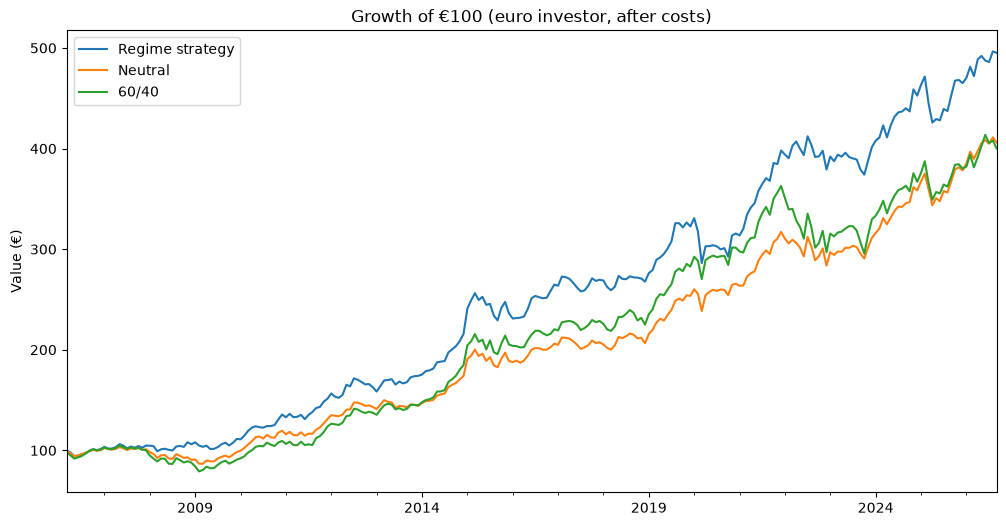

In [26]:
growth.plot(figsize=(12, 6), title="Growth of €100 (euro investor, after costs)")
plt.ylabel("Value (€)")
plt.show()

In [27]:
print(f"Average turnover per year: {turnover_ea.mean() * 12 * 100:.0f}% of the portfolio")
print(f"Total trading costs over the period: {turnover_ea.sum() * COST * 100:.1f}%")

Average turnover per year: 173% of the portfolio
Total trading costs over the period: 3.6%


### Trading activity

Turnover is about **173% of the portfolio per year**, down from 195% in the first version of the model, because the Economic Sentiment Indicator switches less often than industrial production. The portfolio is still repositioned every few months, since the regime changes whenever either growth or inflation switches.

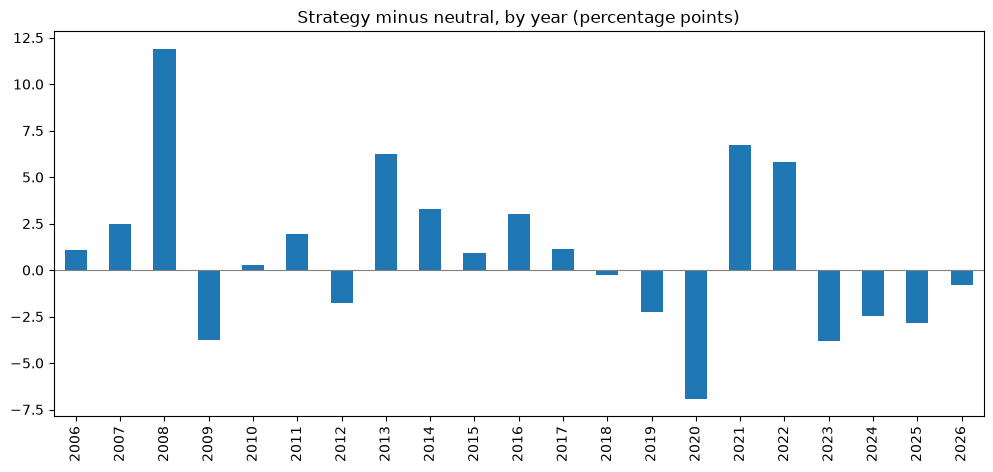

2006     1.1
2007     2.5
2008    11.9
2009    -3.8
2010     0.3
2011     1.9
2012    -1.8
2013     6.3
2014     3.3
2015     0.9
2016     3.0
2017     1.1
2018    -0.3
2019    -2.3
2020    -6.9
2021     6.7
2022     5.8
2023    -3.8
2024    -2.4
2025    -2.8
2026    -0.8
dtype: float64

In [28]:
yearly = (1 + results).groupby(results.index.year).prod() - 1
excess = (yearly["Regime strategy"] - yearly["Neutral"]) * 100

excess.plot(kind="bar", figsize=(12, 5), title="Strategy minus neutral, by year (percentage points)")
plt.axhline(0, color="grey", linewidth=0.8)
plt.show()

excess.round(1)

### Year-by-year

The strategy beat the neutral portfolio in **12 of 21 years**. The pattern is clear:

- **Wins when regimes develop gradually:** 2008 (+11.9 points), when sentiment fell well before the crash; 2013 (+6.3), the recovery from the euro crisis; 2021–2022 (+6.7, +5.8), the reopening boom and the switch to Stagflation the month after Russia's invasion of Ukraine.
- **Losses after sudden shocks:** 2020 (−6.9) and 2009 (−3.8). When sentiment collapses together with markets, the model turns defensive just as markets rebound.
- **Losses in directionless periods:** 2023–2026, four negative years in a row. Sentiment has been flat (about 95–97) since 2023, so it crosses its 12-month average back and forth on small moves, and the regime flips on noise.

**2008 alone contributes more than half of the total outperformance.** Without it, the advantage over the neutral portfolio would be roughly 0.4 points a year.

In [29]:
nets = {}
turns = {}

for lag in range(0, 5):
    sig = regimes["ea_regime"].shift(lag, freq="MS")
    net, _, turn = backtest(returns_eur, sig, regime_weights)
    nets[f"Lag {lag}"] = net
    turns[f"Lag {lag}"] = turn

all_nets = pd.DataFrame(nets).dropna()
all_nets["Neutral"] = results["Neutral"]
all_nets = all_nets.dropna()

lag_table = all_nets.apply(performance)
lag_table.loc["Turnover per year (%)"] = pd.Series(
    {name: t.mean() * 12 * 100 for name, t in turns.items()}
)
lag_table.round(2)

,Lag 0,Lag 1,Lag 2,Lag 3,Lag 4,Neutral
Annual return (%),9.02,8.08,8.06,8.33,7.65,7.04
Volatility (%),7.96,8.55,8.29,8.07,8.03,8.03
Return / volatility,1.13,0.95,0.97,1.03,0.95,0.88
Max drawdown (%),-11.06,-13.54,-10.69,-11.93,-10.53,-16.25
Turnover per year (%),170.04,172.96,172.96,169.55,169.55,NaN


## 5. How much does the publication lag cost?

The backtest was repeated with lags of 0 to 4 months, over the same period. Lag 0 is unrealistic: it assumes each month's regime is known instantly.

| | Lag 0 | **Lag 1** | Lag 2 | Lag 3 | Lag 4 | Neutral |
|---|---|---|---|---|---|---|
| Annual return | 9.02% | **8.08%** | 8.06% | 8.33% | 7.65% | 7.04% |
| Return / volatility | 1.13 | **0.95** | 0.97 | 1.03 | 0.95 | 0.88 |
| Max drawdown | −11.1% | **−13.5%** | −10.7% | −11.9% | −10.5% | −16.3% |

With sentiment data, performance is **similar for lags of 1 to 4 months**; the differences between them are within noise. This contrasts with the first version of the model (industrial production), where the edge fell from 2.3 points at lag 0 to 0.3 points at lag 3.

Likely reasons: sentiment regimes last longer (about 8 months vs 6 for industrial production), so a delay of a few months matters less; and sentiment is forward-looking, so even a few months old it still says something about the economy, while old output data does not.

## 6. Robustness: two halves of the sample

| | 2006–2015 | | | 2016–2026 | | |
|---|---|---|---|---|---|---|
| | **Strategy** | Neutral | 60/40 | **Strategy** | Neutral | 60/40 |
| Annual return | **9.13%** | 6.68% | 7.59% | **7.13%** | 7.38% | 6.40% |
| Return / volatility | **1.05** | 0.80 | 0.77 | **0.85** | 0.95 | 0.66 |
| Max drawdown | **−10.5%** | −16.3% | −24.5% | **−13.5%** | −10.6% | −18.6% |

The strategy clearly beat the neutral portfolio in 2006–2015, but **underperformed it in 2016–2026** on return, risk-adjusted return and drawdown. The whole edge comes from the first decade.

The neutral portfolio beat 60/40 on a risk-adjusted basis **in both halves**. This is the most robust result of the project.

## 7. Model versions

Two versions of the Euro area model were tested. The growth measure was changed for reasons identified **before** looking at backtest results: industrial production is published late, is noisy, and wrongly classified late 2022 as Overheating.

| | Version 1 | Version 2 |
|---|---|---|
| Euro area growth measure | Industrial production | Economic Sentiment Indicator |
| Lag | 3 months | 1 month |
| Annual return (neutral ≈ 7.0%) | 7.31% | 8.08% |
| Return / volatility (neutral 0.87–0.88) | 0.88 | 0.95 |
| Max drawdown | −15.6% | −13.5% |
| Turnover per year | 195% | 173% |

Every additional version tested increases the risk that one looks good by chance. Both versions are therefore reported.

## 8. Conclusions

1. **The regime framework contains information.** With perfect knowledge of the regime, tilts would have added about 2 points a year over a static portfolio.
2. **The choice of growth measure matters more than its speed.** Switching the Euro area from industrial production to the Economic Sentiment Indicator raised the realistic edge from 0.3 to about 1 point a year, and the result barely changed with lags of 1 to 4 months.
3. **The edge is period-dependent.** It comes almost entirely from 2006–2015, mainly 2008. Since 2016 the strategy has not beaten the static portfolio. The model adds value in gradually developing downturns and regime shifts, and loses after sudden shocks and in directionless markets.
4. **Diversification is the robust result.** A static portfolio holding gold, commodities, credit and cash alongside equities and bonds beat 60/40 on a risk-adjusted basis in both halves of the sample.

## 9. Possible extensions

- **Threshold rule:** only switch regime when sentiment moves clearly away from its average, with the threshold set in advance, to reduce switching in flat periods.
- **US / dollar version** of the backtest.
- **Higher trading costs** (e.g. 0.2% per trade).